<a href="https://colab.research.google.com/github/Gokul-S777/ioe-ece5801/blob/main/exp7new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       SMART CITY TRAFFIC MANAGEMENT SYSTEM

Traffic Cycle : 4
Green Signal  : North

Traffic Parameters
-----------------------------------------------------------------
North    | Vehicles: 12 | Speed: 35 km/h | Waiting: 27 sec | Score:  43
South    | Vehicles: 27 | Speed: 39 km/h | Waiting: 28 sec | Score:  43
East     | Vehicles: 14 | Speed: 31 km/h | Waiting: 40 sec | Score:  37
West     | Vehicles: 19 | Speed: 33 km/h | Waiting: 38 sec | Score:  43
-----------------------------------------------------------------


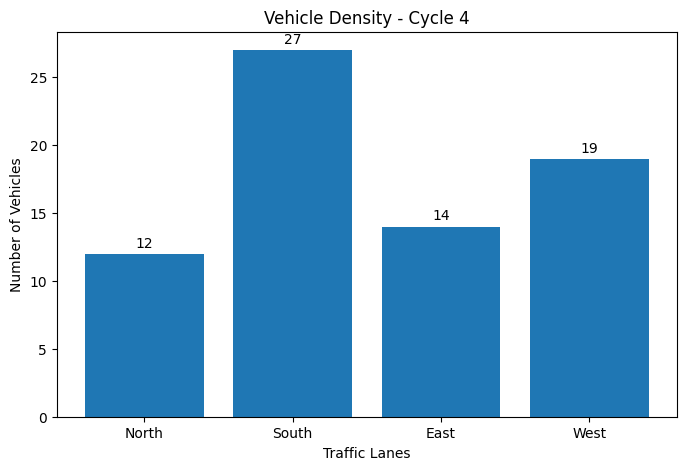

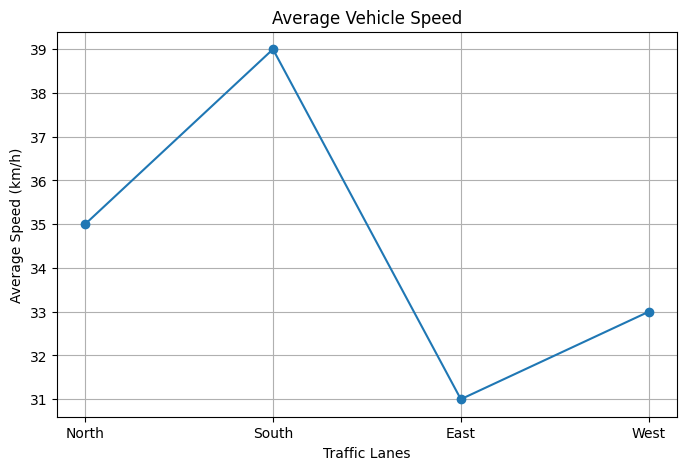

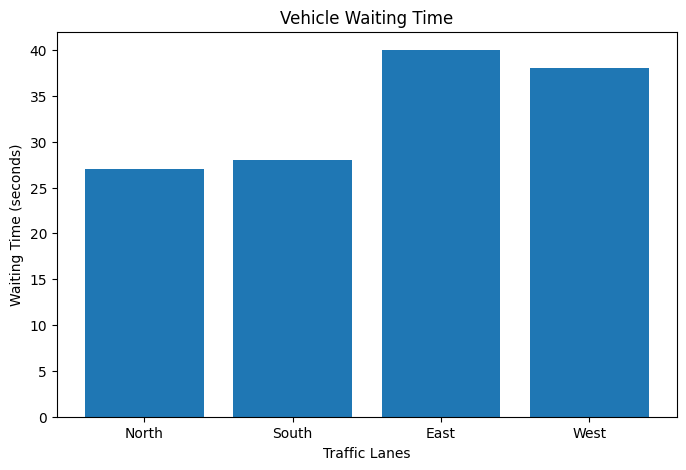


Action: 6 vehicles cleared from North lane.


KeyboardInterrupt: 

In [1]:
# ============================================================
# Smart City Traffic Management System
# Congestion-Aware Traffic Signal Controller
# Google Colab Version
# ============================================================

import random
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# ------------------------------------------------------------
# Lane Names
# ------------------------------------------------------------

lanes = ["North", "South", "East", "West"]

# ------------------------------------------------------------
# Initial Traffic Parameters
# ------------------------------------------------------------

vehicles = [12, 7, 15, 9]

average_speed = [28, 35, 22, 30]   # km/h

waiting_time = [25, 15, 40, 20]    # seconds

simulation_steps = 20

# ------------------------------------------------------------
# Traffic Simulation
# ------------------------------------------------------------

for step in range(1, simulation_steps + 1):

    # New vehicles arrive
    new_vehicles = [
        random.randint(1, 6)
        for _ in range(4)
    ]

    vehicles = [
        vehicles[i] + new_vehicles[i]
        for i in range(4)
    ]

    # Update average speed
    average_speed = [
        max(
            10,
            average_speed[i] + random.randint(-5, 5)
        )
        for i in range(4)
    ]

    # Update waiting time
    waiting_time = [
        waiting_time[i] + random.randint(2, 8)
        for i in range(4)
    ]

    # --------------------------------------------------------
    # Calculate Congestion Score
    # --------------------------------------------------------

    congestion_score = []

    for i in range(4):

        score = (
            vehicles[i] * 2
            + waiting_time[i]
            - average_speed[i]
        )

        congestion_score.append(score)

    # Select most congested lane
    active_lane = congestion_score.index(
        max(congestion_score)
    )

    active_lane_name = lanes[active_lane]

    # --------------------------------------------------------
    # Green Signal Action
    # --------------------------------------------------------

    vehicles_cleared = min(
        vehicles[active_lane],
        random.randint(5, 10)
    )

    vehicles[active_lane] -= vehicles_cleared

    # Reduce waiting time after green signal
    waiting_time[active_lane] = max(
        0,
        waiting_time[active_lane] - 10
    )

    # Increase speed after traffic clearance
    average_speed[active_lane] = min(
        60,
        average_speed[active_lane] + 5
    )

    # --------------------------------------------------------
    # Clear Previous Output
    # --------------------------------------------------------

    clear_output(wait=True)

    print("=" * 65)
    print("       SMART CITY TRAFFIC MANAGEMENT SYSTEM")
    print("=" * 65)

    print(f"\nTraffic Cycle : {step}")
    print(f"Green Signal  : {active_lane_name}")

    print("\nTraffic Parameters")
    print("-" * 65)

    for i in range(4):

        print(
            f"{lanes[i]:8} | "
            f"Vehicles: {vehicles[i]:2} | "
            f"Speed: {average_speed[i]:2} km/h | "
            f"Waiting: {waiting_time[i]:2} sec | "
            f"Score: {congestion_score[i]:3}"
        )

    print("-" * 65)

    # --------------------------------------------------------
    # Graph 1 - Vehicle Density
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.bar(
        lanes,
        vehicles
    )

    plt.xlabel("Traffic Lanes")
    plt.ylabel("Number of Vehicles")
    plt.title(
        f"Vehicle Density - Cycle {step}"
    )

    for i, value in enumerate(vehicles):

        plt.text(
            i,
            value + 0.5,
            str(value),
            ha="center"
        )

    plt.show()

    # --------------------------------------------------------
    # Graph 2 - Average Speed
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        lanes,
        average_speed,
        marker="o"
    )

    plt.xlabel("Traffic Lanes")
    plt.ylabel("Average Speed (km/h)")
    plt.title(
        "Average Vehicle Speed"
    )

    plt.grid(True)

    plt.show()

    # --------------------------------------------------------
    # Graph 3 - Waiting Time
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.bar(
        lanes,
        waiting_time
    )

    plt.xlabel("Traffic Lanes")
    plt.ylabel("Waiting Time (seconds)")
    plt.title(
        "Vehicle Waiting Time"
    )

    plt.show()

    print(
        f"\nAction: {vehicles_cleared} vehicles cleared "
        f"from {active_lane_name} lane."
    )

    # --------------------------------------------------------
    # Next Cycle
    # --------------------------------------------------------

    time.sleep(1.5)

# ------------------------------------------------------------
# Final Message
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("       TRAFFIC SIMULATION COMPLETED")
print("=" * 65)

print("Dynamic congestion-based traffic control completed successfully.")